---

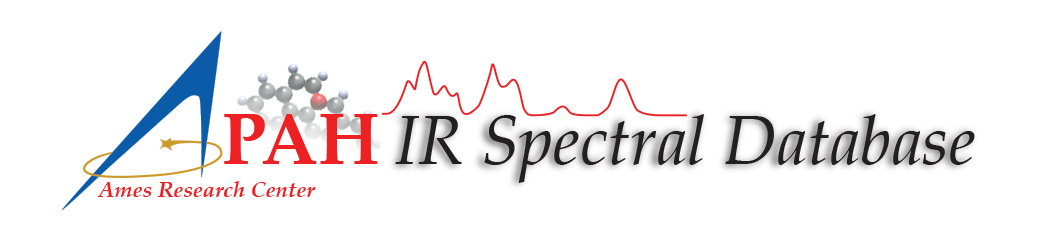

---

# The NASA Ames PAH IR Spectroscopic Database (PAHdb)

[www.astrochemistry.org/pahdb](https://www.astrochemistry.org/pahdb)

## Pypahdb

Developed as part of the JWST PDRs4All Early Release Science (ERS) program (ID 1288).

[pdrs4all.org](https://pdrs4all.org)

---



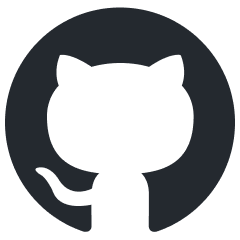

[https://github.com/PAHdb/](https://github.com/PAHdb)

---

## JWebbinar 23
_December 16, 2022_

[Recording](https://drive.google.com/file/d/15h1sbH8y97G4H_3wMc_6yaFlkmO-jGu5/view?usp=sharing) - [Slides](https://www.pdrs4all.org/wp-content/uploads/2022/12/pyPAHdb_JWebbinar.pdf)

---

# pyPAHdb

`Pypahdb` is a Python package to fit and decompose _astronomical PAH emission
spectra_ into contributing PAH subclasses, i.e., charge and size.

A paper describing `pypahdb` was presented at
[SciPy2018](https://scipy2018.scipy.org/) and can be found using its doi:
[https://doi.org/10.25080/Majora-4af1f417-00f](https://doi.org/10.25080/Majora-4af1f417-00f).
However, five years later it is somewhat outdated.

In some ways, `pyPAHdb` can be considered a convenience *light* version of the
[Python](https://github.com/pahdb/amespahdbpythonsuite) and
[IDL](https://github.com/pahdb/amespahdbidlsuite) suites. Documentation
describing `pahdb` can be found
at [https://pahdb.github.io/pyPAHdb/](pahdb.github.io/pyPAHdb/).

`Pypahdb`'s main premise is that it  uses a precomputed matrix of theoretically
calculated PAH emission spectra. This matrix has been constructed from a
collection of "astronomical" PAHs, which meet the following criteria and
includin the fullerenes C<sub>60</sub> and C<sub>70<sub>:

```
'magnesium=0 oxygen=0 iron=0 silicium=0 chx=0 ch2=0 c>20 hydrogen>0'
```

The PAH emission spectra have been calculated employing a PAH emission model
with the following parameters:

- A calculated vibrational temperature upon the absorption of a 7 eV photon,
- A calculated integrated band intensity after following the entire emission cascade,
- A redshift of 15 cm<sup>-1</sup> to mimic some effects of *anharmonicity*, and
- A Gaussian emission profile with a FWHM of 15 cm<sup>-1</sup>.

### Methodology

The methodology `pypahdb` uses is summarized in the following flowchart and
consists of three steps: (1) Astronomical spectroscopic data is loaded, whether
from FITS or ASCII files; (2) An over-sampled pre-computed matrix of PAH spectra
is read and interpolated onto the wavelength grid of the astronomical observations.
Database-fitting is performed using non-negative least-squares (NNLS), which
yields the contribution of an individual PAH molecule to the total fit. As a
resul a breakdown of the model fit in terms of PAH charge and size
is obtained; and (3) The results are written to disk as a single FITS file and as a PDF
summarizing the results (one page per pixel, if a spectral cube is provided as
input).

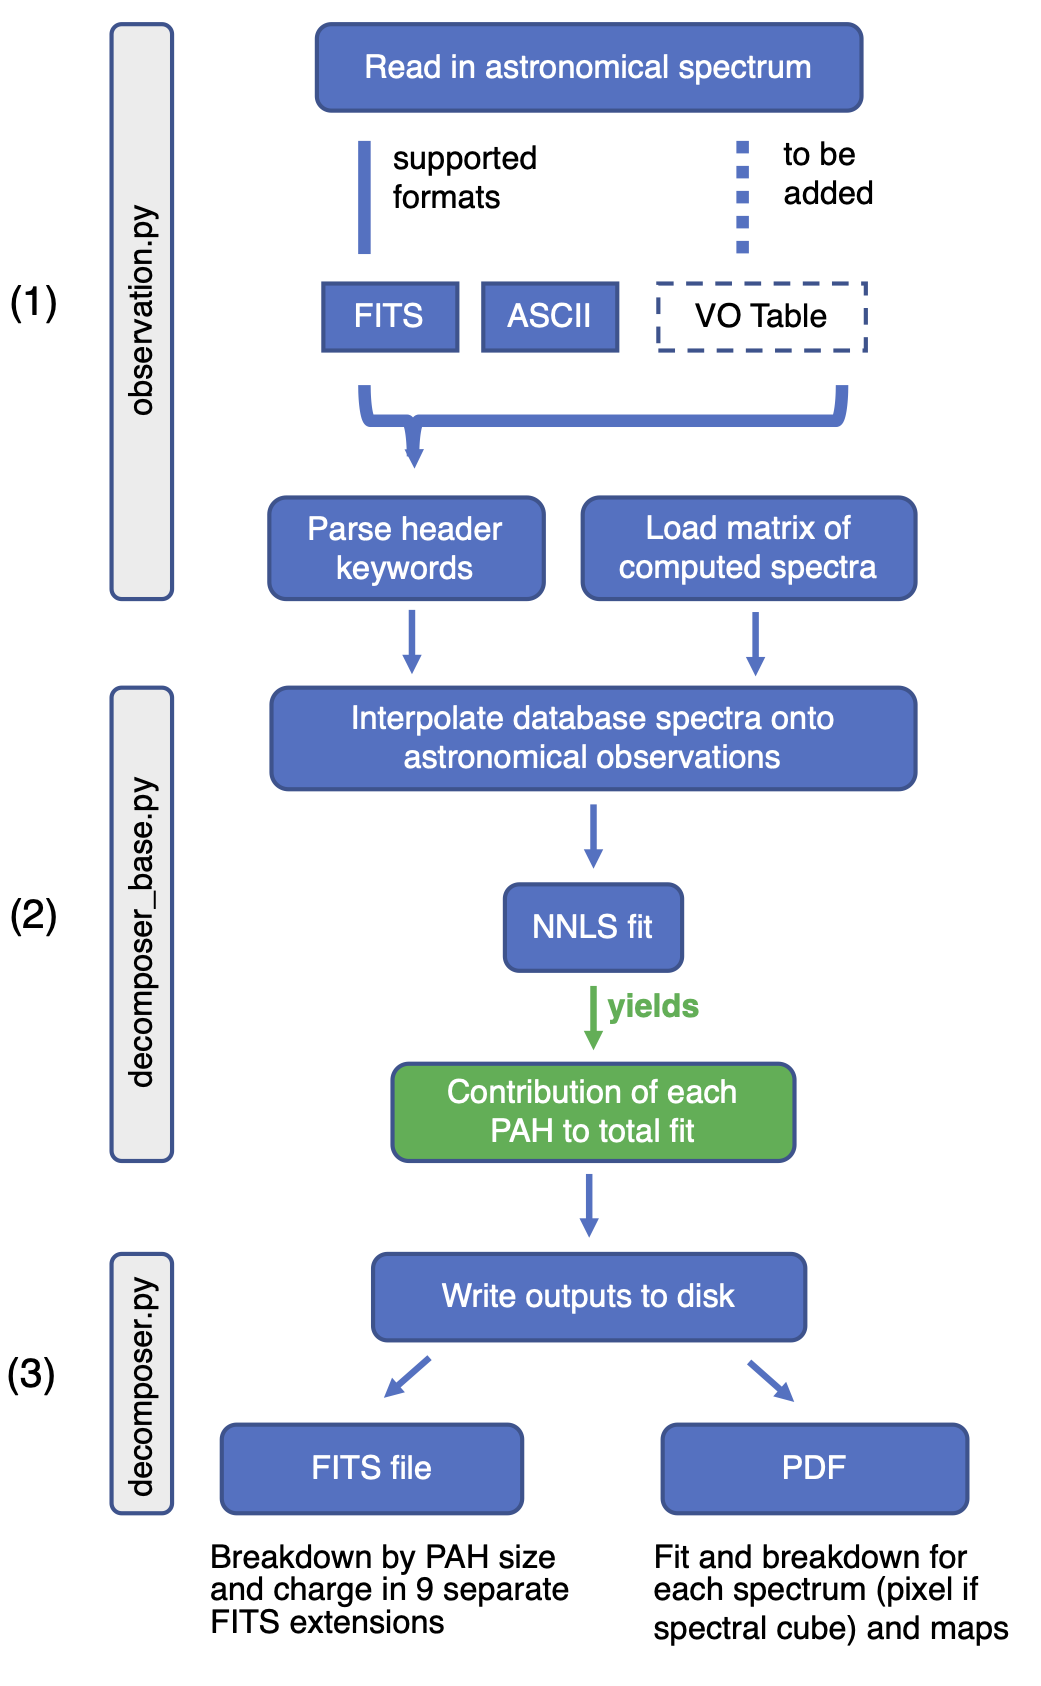

---

# Demo

### Installation

*!!! ONLY NEEDED IF PYPAHDB ISN'T INSTALLED ON YOUR SYSTEM YET !!!*

In [ ]:
%pip install git+https://github.com/PAHdb/pyPAHdb.git

### Performing a Fit to a Single JWST Spectrum*

*_redshift corrected_ from ERS program 1328 and _following `example_jwst.py` that can be found in the `examples`-directory of
`pypahdb`_.

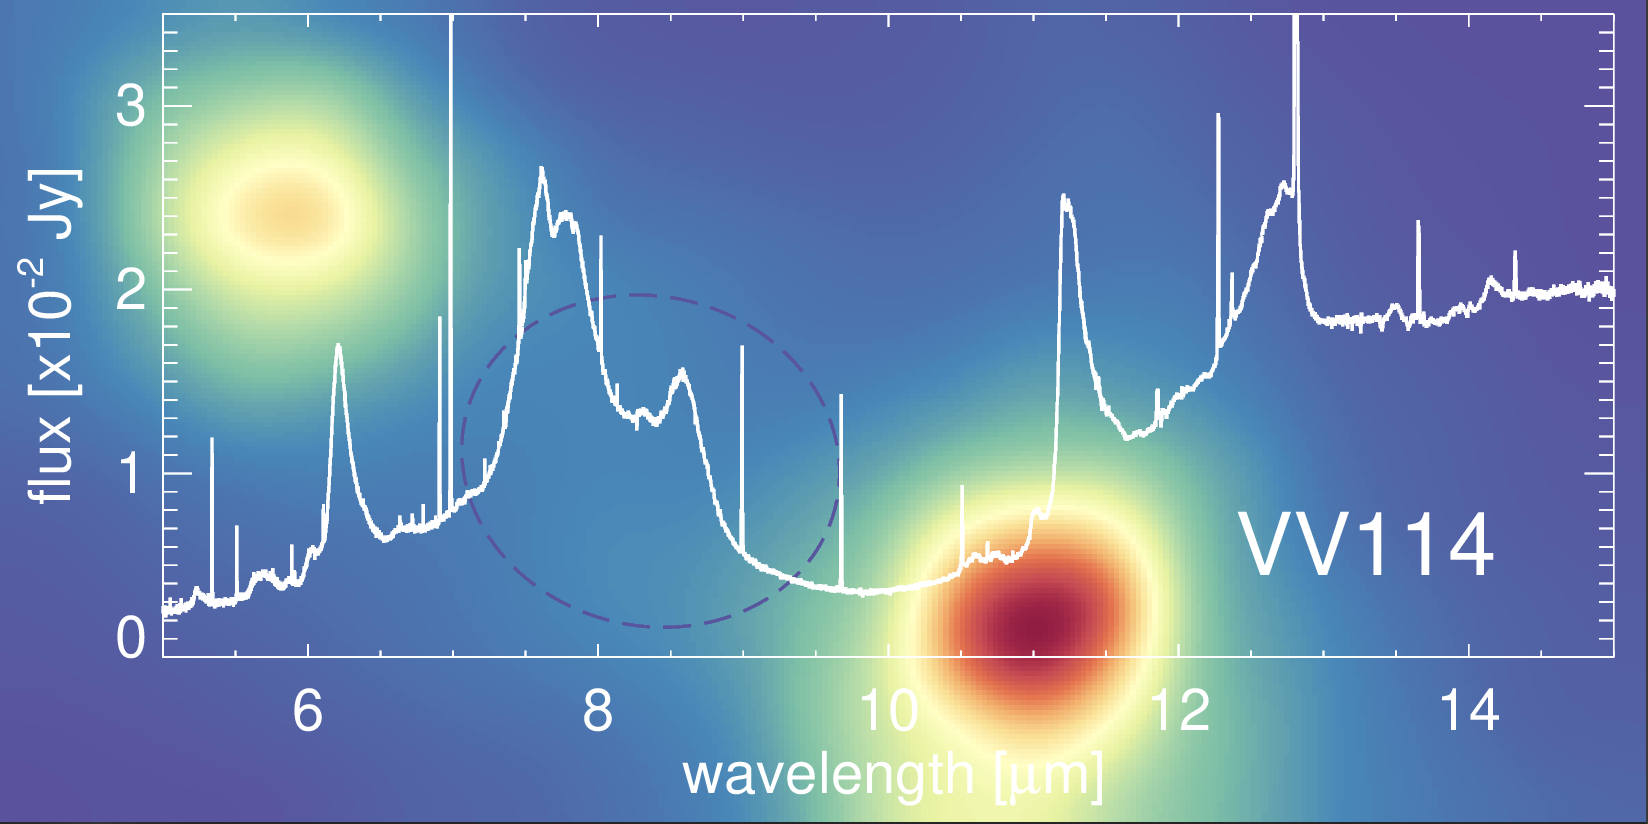

### Imports

In [ ]:
import importlib_resources
import copy
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

from astropy.wcs import WCS
from astropy.io import fits

from pypahdb.observation import Observation
from pypahdb.decomposer import Decomposer

### Read-in Observations and Perform Fit

In [ ]:
# Sample JWST data (IPAC table)
file_path = importlib_resources.files("pypahdb")
data_file = file_path / "resources/sample_data_VV114E.tbl"

# Construct an Observation object.
obs = Observation(data_file)

# Pass the Observation's spectrum to Decomposer, which performs the fit.
fit = Decomposer(obs.spectrum)

### Display Single Spectrum Fit Results

In [ ]:
fig = fit.plot_fit()

### Retrieve the PAH Ionization  and Size Fraction

In [ ]:

for k, v in fit.charge_fractions.items():
    print(f"{k.upper():7.7}: {100.0*v[0,0]:0.1f}%")

for k, v in fit.size_fractions.items():
    print(f"{k.upper():7.7}: {100.0*v[0,0]:0.1f}%")

### Performing a Fit to a Spitzer Spectral Cube*
*_Approach would be the same for a JWST spectral Cube_ and _following `example_fits.py` that can be found in the `examples`-directory of
`pypahdb`_.

#### The Reflection Nebula NGC 7023 (Iris Nebula)

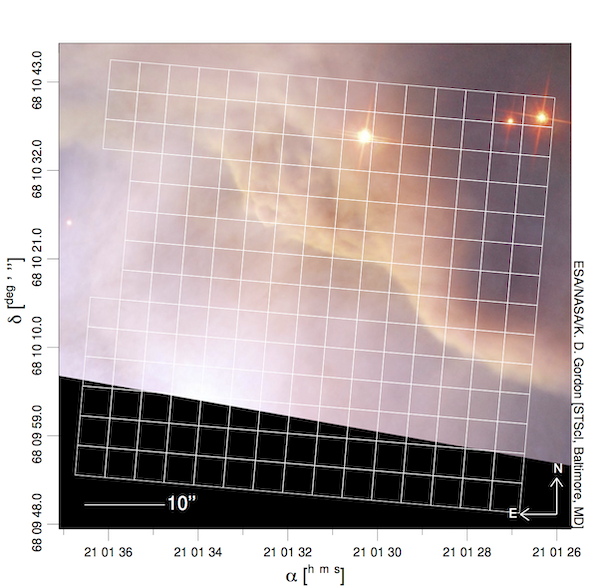

In [ ]:
# Sample Spitzer spectral cube (in FITS format)
file_path = importlib_resources.files("pypahdb")
data_file = file_path / "resources/sample_data_NGC7023.fits"

# Construct an Observation object
obs = Observation(data_file)

# Pass the Observation's spectrum to Decomposer, which performs the fit
fit = Decomposer(obs.spectrum)

### Display Spectral Cube Results

A convenience function to clean up WCS header information.

In [ ]:
# Remove 3rd axis
def fix_header(header):
  hdr = copy.deepcopy(header)
  hdr['NAXIS'] = 2
  cards = ['NAXIS3', 'PC3_3', 'CRPIX3',
           'CRVAL3', 'CTYPE3', 'CDELT3',
           'CUNIT3', 'PS3_0', 'PS3_1',
           'WCSAXES']
  for c in cards:
    if c in hdr:
      del hdr[c]

  return hdr

In [ ]:
# Display map of the PAH ionization fraction
fig = fit.plot_map(fit.cation_neutral_ratio.value,
             r"n$_{cation}$/n$_{neutral}$",
              WCS(fix_header(obs.header))
)

In [ ]:
# Display map of the PAH neutral fraction
fig = fit.plot_map(fit.charge_fractions["neutral"],
             "PAH neutral fraction",
              WCS(fix_header(obs.header))
)

### Display Single Pixel Fit Results

In [ ]:
# Pixel position (10,10)
fig = fit.plot_fit(10,10)

### Inspecting Results Directly

In [ ]:
# Cube with fitted spectra
print(fit.fit.shape)

# Nine maps of derived parameters
print(fit.charge_fractions.keys())
print(fit.size_fractions.keys())
print(fit.error.shape)
print(fit.nc.shape)
print(fit.cation_neutral_ratio.shape)

# Two spectra cubes with the breakdowns
print(fit.size.keys())
print(fit.charge.keys())

### Saving Results to File

In [ ]:
# Save results to PDF - don't plot each spectral fit!
fit.save_pdf('NGC7023_pypahdb.pdf', header=obs.header, doplots=False)

# Save results to FITS
fit.save_fits('NGC7023_pypahdb_fit.fits', header=obs.header)

#### Inspecting the Output

In [ ]:
# Load back in the FITS file that was saved in the cell above
with fits.open("NGC7023_pypahdb_fit.fits") as hdulist:

  # Print FITS-file info
  hdulist.info()

  # Print the header 'nicely'
  print()
  for key, value in hdulist["PRIMARY"].header.items():
      print(f"{key} = {value}")
  print()


  # Display map of the large PAH fraction 
  Decomposer.plot_map(hdulist["LARGE"].data,
                      "large fraction",
                      WCS(hdulist["PRIMARY"].header)
                     )